In [1]:
# Delivery Delay Intelligence 
# project path---> dataset- datacleaning- eda -visualization -insights -ml later

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("C:/Users/venka/Downloads/delivery_five_cities.csv")
df.head()

,order_id,from_dipan_id,from_city_name,delivery_user_id,poi_lng,poi_lat,aoi_id,typecode,receipt_time,receipt_lng,receipt_lat,sign_time,sign_lng,sign_lat,ds
0,687227b4d0c733049b16ccd566db6e01,08331170e24742ba7a3938f5b34ff24d,上海市,18ff78d2069125937a847fb701a9db6c,1.056351e+07,-7.458321e+06,e0581ca18e7ca371a9869e041cb09075,4602b38053ece07a9ca5153f1df2e404,03-18 13:35:00,1.056160e+07,-7.457998e+06,03-18 14:51:00,NaN,NaN,318
1,55be8cdf1270526231c9ba3387f51b54,c5ac5ba99801aa6b85ba473d9260512b,重庆市,df0b594618d1ba6f619e4e7dd034447c,8.899874e+06,-7.684936e+06,9c0f96ff01a71477334ef563001abc72,203ac3454d75e02ebb0a3c6f51d735e4,03-18 08:32:00,8.900992e+06,-7.686103e+06,03-18 14:33:00,NaN,NaN,318
2,ee46cae9ba2c002451af3c6fbcb49410,2129bfb99a2f6c11000c0ecbf1a5f3f6,上海市,05cceaaa5db96756294dd6d573fd865d,1.058131e+07,-7.467397e+06,4de9bf7f155046e7d0fd400672ab9cf3,203ac3454d75e02ebb0a3c6f51d735e4,03-18 13:02:00,1.058124e+07,-7.467607e+06,03-18 15:34:00,NaN,NaN,318
3,38912be86c83138901b5e26398832be7,08331170e24742ba7a3938f5b34ff24d,上海市,f29e97ef8398477abb72b852b16c91c0,1.056273e+07,-7.456804e+06,fe48cde9b33e2308641d985f8a701c7e,203ac3454d75e02ebb0a3c6f51d735e4,03-18 12:11:00,1.056160e+07,-7.457997e+06,03-18 14:08:00,NaN,NaN,318
4,2b83e2ba16714fee357694964d0e7e41,4fe96250270c2e17a28016a5fba4bc4a,杭州市,1d00e6f2308aad233f0179aac63aa23d,1.044847e+07,-7.587086e+06,a7d4de5484ca867fe453976ba9fee424,4602b38053ece07a9ca5153f1df2e404,03-18 07:28:00,1.044791e+07,-7.586259e+06,03-20 12:40:00,NaN,NaN,318


In [3]:
df.shape

(472419, 15)

In [4]:
df["from_city_name"]


0         上海市
1         重庆市
2         上海市
3         上海市
4         杭州市
         ... 
472414    重庆市
472415    杭州市
472416    上海市
472417    重庆市
472418    重庆市
Name: from_city_name, Length: 472419, dtype: object

In [5]:
df=df.drop(columns=["sign_lng","sign_lat"])
df.columns

Index(['order_id', 'from_dipan_id', 'from_city_name', 'delivery_user_id',
       'poi_lng', 'poi_lat', 'aoi_id', 'typecode', 'receipt_time',
       'receipt_lng', 'receipt_lat', 'sign_time', 'ds'],
      dtype='object')

In [6]:
df.shape
df.dtypes
df.duplicated().sum()

np.int64(0)

In [7]:
df["typecode"].unique()
df["typecode"].value_counts().head(10)

typecode
203ac3454d75e02ebb0a3c6f51d735e4    290465
fe76dff35bb199cdb7329eba2b918f18    121854
14cca3f2714c7c0faf2cbac10ba12d3b     16671
4602b38053ece07a9ca5153f1df2e404     12864
339d14e62a5bbd67de62f461a5f7db1e      8850
73ffcbd1b26557b462b14e4dd4c57fcb      7241
84c7d46d654e5a8bd329a3e8ed0293ce      4554
e83a6cefa7e4bde8a8af866f3f4e90eb      2557
7a0cb6a50445e24c12a407687b28fa06      1419
37b081598a86e85e8887b0539ab61824      1386
Name: count, dtype: int64

In [8]:
df[["receipt_time","sign_time"]].isnull().sum()

receipt_time    0
sign_time       0
dtype: int64

In [9]:
df["ds"].head(10)
df["ds"].unique()
df[["ds","receipt_time","sign_time"]].head(10)

,ds,receipt_time,sign_time
0,318,03-18 13:35:00,03-18 14:51:00
1,318,03-18 08:32:00,03-18 14:33:00
2,318,03-18 13:02:00,03-18 15:34:00
3,318,03-18 12:11:00,03-18 14:08:00
4,318,03-18 07:28:00,03-20 12:40:00
5,318,03-18 09:53:00,03-18 10:29:00
6,318,03-18 08:26:00,03-18 09:58:00
7,318,03-18 08:26:00,03-18 12:54:00
8,318,03-18 08:37:00,03-18 10:37:00
9,318,03-18 07:53:00,03-18 10:04:00


In [10]:
df["receipt_time"].head(20)
df["sign_time"].head(20)

0     03-18 14:51:00
1     03-18 14:33:00
2     03-18 15:34:00
3     03-18 14:08:00
4     03-20 12:40:00
5     03-18 10:29:00
6     03-18 09:58:00
7     03-18 12:54:00
8     03-18 10:37:00
9     03-18 10:04:00
10    03-18 08:14:00
11    03-18 10:03:00
12    03-18 08:41:00
13    03-18 11:26:00
14    03-18 20:18:00
15    03-18 09:57:00
16    03-18 18:39:00
17    03-18 09:03:00
18    03-18 18:01:00
19    03-18 17:30:00
Name: sign_time, dtype: object

In [11]:
df["receipt_time"]=pd.to_datetime("2022-"+df["receipt_time"].astype(str),format="%Y-%m-%d %H:%M:%S",errors="coerce")
df["sign_time"]=pd.to_datetime("2022-"+df["sign_time"].astype(str),format="%Y-%m-%d %H:%M:%S",errors="coerce")

In [12]:
df[["receipt_time","sign_time"]].dtypes

receipt_time    datetime64[ns]
sign_time       datetime64[ns]
dtype: object

In [13]:
df["delivery_duration"]=(df["sign_time"]-df["receipt_time"]).dt.total_seconds()/3600

In [14]:
df[["receipt_time","sign_time","delivery_duration"]].head()

,receipt_time,sign_time,delivery_duration
0,2022-03-18 13:35:00,2022-03-18 14:51:00,1.266667
1,2022-03-18 08:32:00,2022-03-18 14:33:00,6.016667
2,2022-03-18 13:02:00,2022-03-18 15:34:00,2.533333
3,2022-03-18 12:11:00,2022-03-18 14:08:00,1.950000
4,2022-03-18 07:28:00,2022-03-20 12:40:00,53.200000


In [15]:
df[df["delivery_duration"]<0][["receipt_time","sign_time","delivery_duration"]].head(10)

,receipt_time,sign_time,delivery_duration
34022,2022-03-25 16:50:00,2022-03-23 08:48:00,-56.033333
35312,2022-03-28 17:08:00,2022-03-23 16:19:00,-120.816667
42762,2022-03-26 17:35:00,2022-03-23 14:52:00,-74.716667
49250,2022-03-24 18:29:00,2022-03-23 16:24:00,-26.083333
56892,2022-03-31 12:52:00,2022-03-25 10:37:00,-146.250000
58572,2022-03-24 17:48:00,2022-03-23 11:40:00,-30.133333
96828,2022-04-03 16:37:00,2022-03-28 20:08:00,-140.483333
101137,2022-03-31 18:10:00,2022-03-28 16:04:00,-74.100000
102203,2022-04-02 09:08:00,2022-03-28 08:55:00,-120.216667
103337,2022-04-01 15:04:00,2022-03-28 14:24:00,-96.666667


In [16]:
df=df[df["delivery_duration"]>=0]

In [17]:
(df["delivery_duration"]<0).sum()
(df["delivery_duration"]==0).sum()
(df["delivery_duration"]<=10).sum()
(df["delivery_duration"]).max()

530.5

In [18]:
len(df)

472353

In [19]:
df["delivery_duration"].describe()

count    472353.000000
mean          2.945974
std           8.507154
min           0.000000
25%           0.866667
50%           1.550000
75%           2.750000
max         530.500000
Name: delivery_duration, dtype: float64

In [20]:
df.sort_values("delivery_duration",ascending=False)[["receipt_time","sign_time","delivery_duration"]].head(10)

,receipt_time,sign_time,delivery_duration
205890,2022-03-22 08:51:00,2022-04-13 11:21:00,530.500000
18047,2022-03-18 15:16:00,2022-04-09 12:22:00,525.100000
45849,2022-03-23 07:58:00,2022-04-12 16:03:00,488.083333
380793,2022-03-20 09:19:00,2022-04-09 15:47:00,486.466667
351639,2022-03-21 08:57:00,2022-04-10 11:32:00,482.583333
346947,2022-03-21 07:04:00,2022-04-09 11:59:00,460.916667
219275,2022-03-22 08:28:00,2022-04-09 19:17:00,442.816667
359616,2022-03-21 08:48:00,2022-04-08 17:15:00,440.450000
268898,2022-03-24 11:40:00,2022-04-11 11:15:00,431.583333
412224,2022-03-27 09:34:00,2022-04-13 17:05:00,415.516667


In [21]:
(df["delivery_duration"]>24).sum()
(df["delivery_duration"]>24).mean()*100

np.float64(1.4753796419203435)

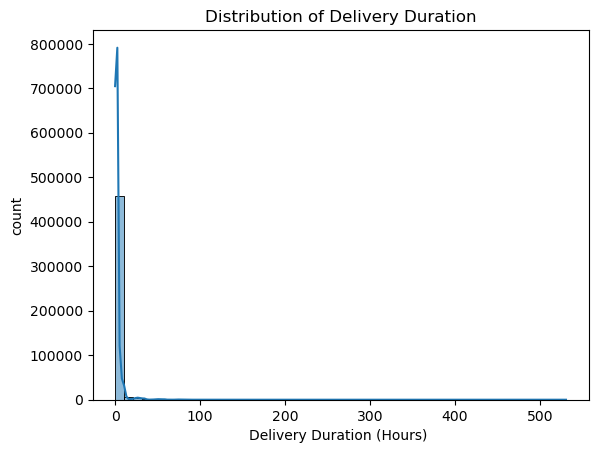

In [22]:
sns.histplot(df["delivery_duration"],bins=50,kde=True)
plt.xlabel("Delivery Duration (Hours) ")
plt.ylabel("count")
plt.title("Distribution of Delivery Duration")
plt.show()



C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28023 (\N{CJK UNIFIED IDEOGRAPH-6D77}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24198 (\N{CJK UNIFIED IDEOGRAPH-5E86}) missing from font(s) DejaVu San

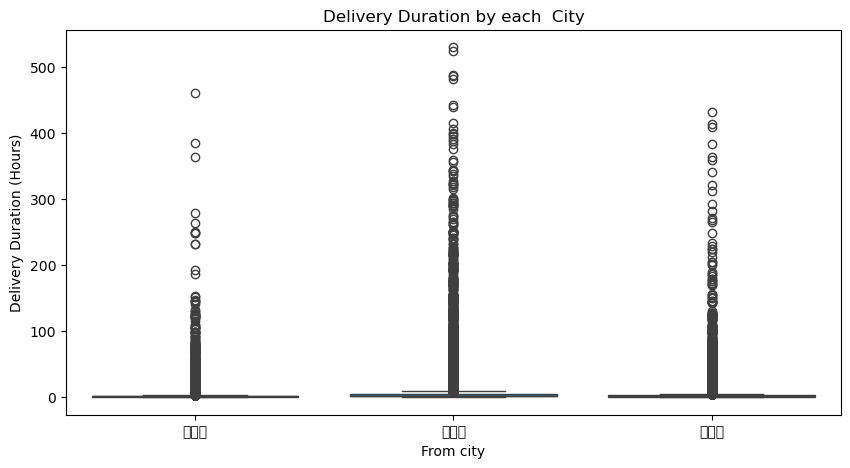

In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(x="from_city_name",y="delivery_duration",data=df)
plt.xlabel("From city")
plt.ylabel("Delivery Duration (Hours)")
plt.title("Delivery Duration by each  City")
plt.show()


In [24]:
df.groupby("from_city_name")["delivery_duration"].mean()

from_city_name
上海市    1.766743
杭州市    2.440485
重庆市    5.329877
Name: delivery_duration, dtype: float64

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28023 (\N{CJK UNIFIED IDEOGRAPH-6D77}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26477 (\N{CJK UNIFIED IDEOGRAPH-676D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24030 (\N{CJK UNIFIED IDEOGRAPH-5DDE}) missing from font(s) DejaVu San

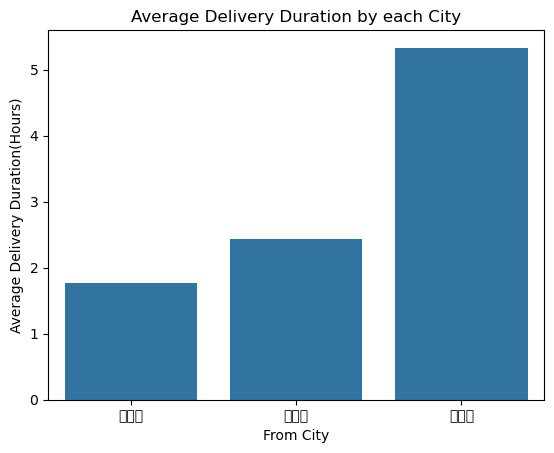

In [25]:
avg_delivery=df.groupby("from_city_name")["delivery_duration"].mean()
sns.barplot(x=avg_delivery.index,
           y=avg_delivery.values
           )
plt.xlabel("From City")
plt.ylabel("Average Delivery Duration(Hours)")
plt.title("Average Delivery Duration by each City")
plt.show()

In [26]:
df.groupby("from_city_name")["delivery_duration"].mean()

from_city_name
上海市    1.766743
杭州市    2.440485
重庆市    5.329877
Name: delivery_duration, dtype: float64

In [27]:
df.groupby("typecode")["delivery_duration"].mean().sort_values(ascending=False)

typecode
4602b38053ece07a9ca5153f1df2e404    10.417930
b5a9c025f39653c16fb88f576bc669d0     7.288571
90b3cbb280f865d62b2fd2efdd0fb0f3     3.928339
37b081598a86e85e8887b0539ab61824     3.748100
e8b508bbdada69046e4dd74ef59ee85a     3.370925
592363aed428fd9addffa38da2724834     3.299631
7a0cb6a50445e24c12a407687b28fa06     3.128212
fe76dff35bb199cdb7329eba2b918f18     3.056088
e83a6cefa7e4bde8a8af866f3f4e90eb     2.767619
73ffcbd1b26557b462b14e4dd4c57fcb     2.655114
203ac3454d75e02ebb0a3c6f51d735e4     2.588413
6771c4e2ecb275c95c43f6c639a2cbad     2.453326
84c7d46d654e5a8bd329a3e8ed0293ce     2.414445
339d14e62a5bbd67de62f461a5f7db1e     2.150788
14cca3f2714c7c0faf2cbac10ba12d3b     2.146709
Name: delivery_duration, dtype: float64

In [28]:
df["typecode"].value_counts().head(10)

typecode
203ac3454d75e02ebb0a3c6f51d735e4    290446
fe76dff35bb199cdb7329eba2b918f18    121824
14cca3f2714c7c0faf2cbac10ba12d3b     16671
4602b38053ece07a9ca5153f1df2e404     12864
339d14e62a5bbd67de62f461a5f7db1e      8841
73ffcbd1b26557b462b14e4dd4c57fcb      7241
84c7d46d654e5a8bd329a3e8ed0293ce      4547
e83a6cefa7e4bde8a8af866f3f4e90eb      2556
7a0cb6a50445e24c12a407687b28fa06      1419
37b081598a86e85e8887b0539ab61824      1386
Name: count, dtype: int64

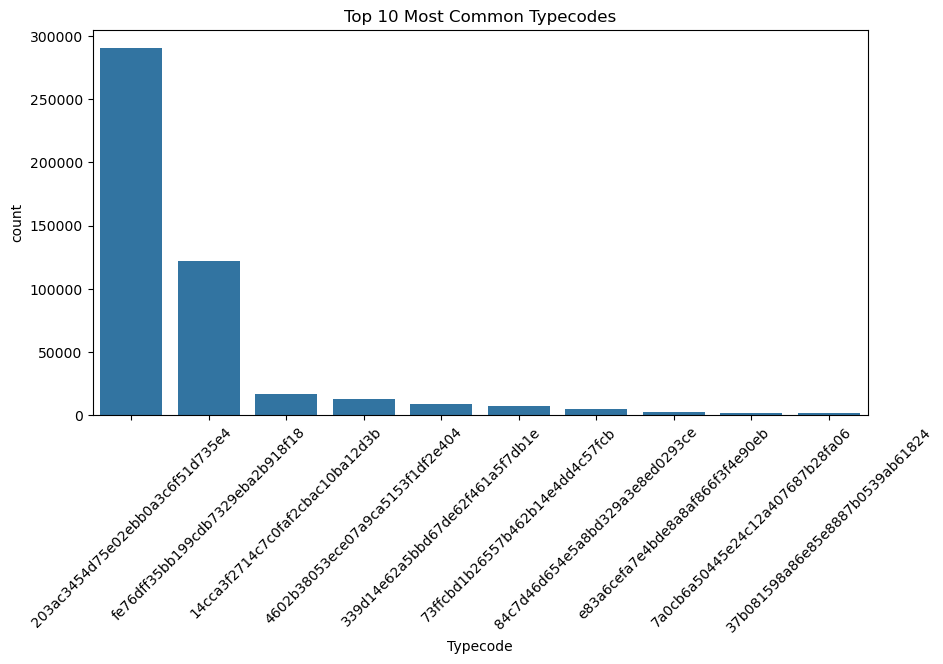

In [29]:
top_typecodes=df["typecode"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_typecodes.index,
           y=top_typecodes.values)
plt.xlabel("Typecode")
plt.ylabel("count")
plt.title("Top 10 Most Common Typecodes")
plt.xticks(rotation=45)
plt.show()


In [30]:
top_10_codes=df["typecode"].value_counts().head(10).index
df[df["typecode"].isin(top_10_codes)].groupby("typecode")["delivery_duration"].mean().sort_values(ascending=False)

typecode
4602b38053ece07a9ca5153f1df2e404    10.417930
37b081598a86e85e8887b0539ab61824     3.748100
7a0cb6a50445e24c12a407687b28fa06     3.128212
fe76dff35bb199cdb7329eba2b918f18     3.056088
e83a6cefa7e4bde8a8af866f3f4e90eb     2.767619
73ffcbd1b26557b462b14e4dd4c57fcb     2.655114
203ac3454d75e02ebb0a3c6f51d735e4     2.588413
84c7d46d654e5a8bd329a3e8ed0293ce     2.414445
339d14e62a5bbd67de62f461a5f7db1e     2.150788
14cca3f2714c7c0faf2cbac10ba12d3b     2.146709
Name: delivery_duration, dtype: float64

In [31]:
df.groupby("from_city_name")["delivery_duration"].mean().sort_values(ascending=True).head(10)

from_city_name
上海市    1.766743
杭州市    2.440485
重庆市    5.329877
Name: delivery_duration, dtype: float64

In [32]:
df.groupby("from_city_name")["delivery_duration"].median().sort_values(ascending=True)

from_city_name
上海市    1.233333
杭州市    1.550000
重庆市    2.416667
Name: delivery_duration, dtype: float64

In [33]:
df.groupby("from_city_name")["delivery_duration"].mean().sort_values(ascending=False).head(10)

from_city_name
重庆市    5.329877
杭州市    2.440485
上海市    1.766743
Name: delivery_duration, dtype: float64